# Ocean and land surface state

`SST` and `SSS` are the top level of `TEMP` and `SALT`; `MLD` converts `XMXL` from
centimetres to metres; `LST` is surface temperature masked to where `LANDFRAC > 0.5`
— a good example of a diagnostic that needs *two* input fields. The bundled 3-D
ocean fields cover year 1 only.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
from x4c import diags

case = x4c.Timeseries(case_dir, grid_dict={'atm': 'ne16np4', 'ocn': 'g16'},
                      cesm_ver=1)

>>> case.root_dir: /glade/u/home/fengzhu/.cache/x4c/sample_data/cesm1_sample_data/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["ice"]["cice.h"] created


In [3]:
ssh_path = os.path.join(case_dir, 'ocn', 'proc', 'tseries', 'month_1',
                        f'{casename}.pop.h.SSH.000101-000512.nc')
ssv = x4c.open_dataset(ssh_path, comp='ocn', grid='g16', vn='SSH',
                       shift_time=True).x.regrid().x.da.mean('time')

In [4]:
ocean = {}
for vn, span in [('SST', (1, 1)), ('SSS', (1, 1)), ('MLD', (1, 10))]:
    case.load(vn, timespan=span, verbose=False)
    da = case.ds[vn]
    ocean[vn] = da
    print(f'  {vn:5s} {str(dict(da.sizes)):48s} {da.attrs.get("units")}')

  SST   {'time': 12, 'nlat': 384, 'nlon': 320}           °C
  SSS   {'time': 12, 'nlat': 384, 'nlon': 320}           gram/kilogram


  MLD   {'time': 120, 'nlat': 384, 'nlon': 320}          m


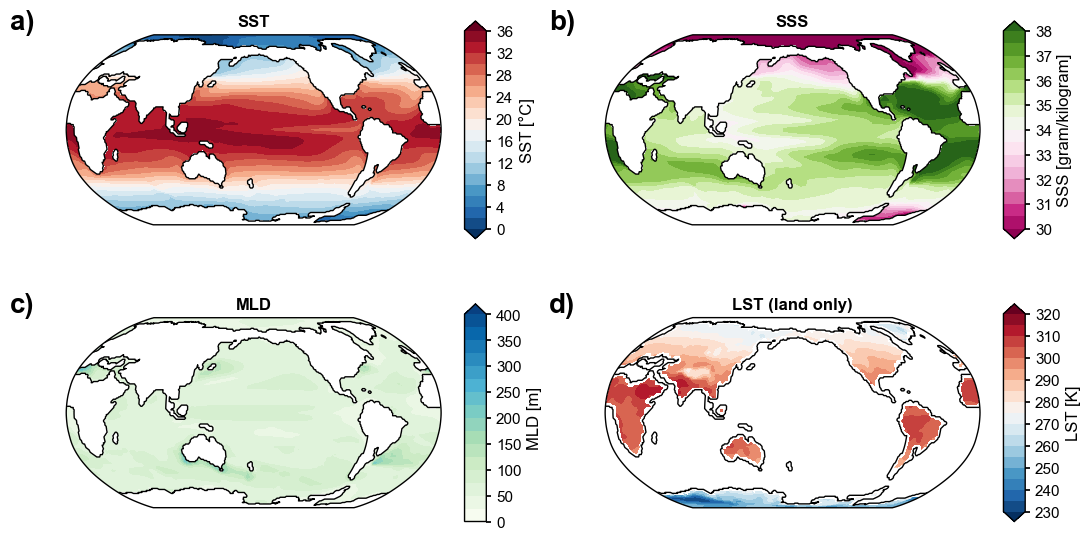

In [5]:
ax_loc = {'a': (0, 0), 'b': (0, 1), 'c': (1, 0), 'd': (1, 1)}
fig, axd = x4c.subplots(2, 2, ax_loc=ax_loc,
                        projs={k: 'Robinson' for k in ax_loc},
                        projs_kws={k: {'central_longitude': 180} for k in ax_loc},
                        figsize=(13, 6.5), wspace=0.15, hspace=0.3, annotation=True)

ocean['SST'].x.regrid(2, 2).mean('time').x.plot(
    ax=axd['a'], ssv=ssv, levels=np.linspace(0, 36, 19), title='SST')
ocean['SSS'].x.regrid(2, 2).mean('time').x.plot(
    ax=axd['b'], ssv=ssv, levels=np.linspace(30, 38, 17), title='SSS')
ocean['MLD'].x.regrid(2, 2).x.annualize().mean('time').x.plot(
    ax=axd['c'], ssv=ssv, extend='max', levels=np.linspace(0, 400, 17), title='MLD')

case.load('LST', timespan=(1, 10), verbose=False)
case.ds['LST'].x.regrid(2, 2).x.annualize().mean('time').x.plot(
    ax=axd['d'], ssv=ssv, levels=np.linspace(230, 320, 19),
    title='LST (land only)')
x4c.showfig(fig)